# Mistake Identification in Pedagogical Conversations

## Mistake Identification in Pedagogical Conversations

### Problem Statement
Given a tutoring conversation where a student makes a mistake, classify whether the tutor's response successfully identifies the student's mistake.

**Classification Labels:**
- **Yes**: The tutor clearly identifies the mistake
- **To some extent**: The tutor partially addresses the mistake
- **No**: The tutor does not identify the mistake

### Dataset Structure
- **trainset.json**: 300 conversations with labels (2,400 samples) - Used for training
- **dev_testset.json**: 41 conversations WITHOUT labels (328 samples) - For inference/predictions
- **testset.json**: 150 conversations WITHOUT labels (1,200 samples) - For final predictions

### Approach
We'll use a fine-tuned transformer model for sequence classification:

1. **Model Choice**: DeBERTa-v3-base for excellent reasoning capabilities
2. **Training Strategy**: Train on trainset with validation split
3. **Evaluation**: Make predictions on dev and test sets
4. **Output**: Save predictions as CSV files for each model's responses

## 1. Import the dataset

In [1]:
import json

# Read all JSON files
json_files = [
    '/DATA/cs24mtech12016/repos/pedagogical-assessment/data/dev_testset.json',
    '/DATA/cs24mtech12016/repos/pedagogical-assessment/data/testset.json',
    '/DATA/cs24mtech12016/repos/pedagogical-assessment/data/trainset.json'
]

all_conversation_ids = set()

for file_path in json_files:
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
            for item in data:
                if 'conversation_id' in item:
                    all_conversation_ids.add(item['conversation_id'])
        print(f"Loaded {file_path}: {len([item for item in data if 'conversation_id' in item])} conversations")
    except FileNotFoundError:
        print(f"File not found: {file_path}")
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

print(f"\nTotal unique conversation IDs across all files: {len(all_conversation_ids)}")

Loaded /DATA/cs24mtech12016/repos/pedagogical-assessment/data/dev_testset.json: 41 conversations
Loaded /DATA/cs24mtech12016/repos/pedagogical-assessment/data/testset.json: 150 conversations
Loaded /DATA/cs24mtech12016/repos/pedagogical-assessment/data/trainset.json: 300 conversations

Total unique conversation IDs across all files: 491


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

/DATA/cs24mtech12016/.conda/envs/indoml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.8.0+cu128
CUDA available: True
Device: NVIDIA RTX 6000 Ada Generation


## 2. Load and Explore Data

Loading datasets...
Note: Train set has labels, Dev/Test sets are for prediction only

Dataset Statistics
Training samples (with labels): 2476
Dev samples (for inference): 333
Test samples (for inference): 2476

Training Set Label Distribution
label
Yes               1407
No                 566
To some extent     503
Name: count, dtype: int64

📝 Note: Dev and Test sets don't have labels - they're for prediction/inference only!


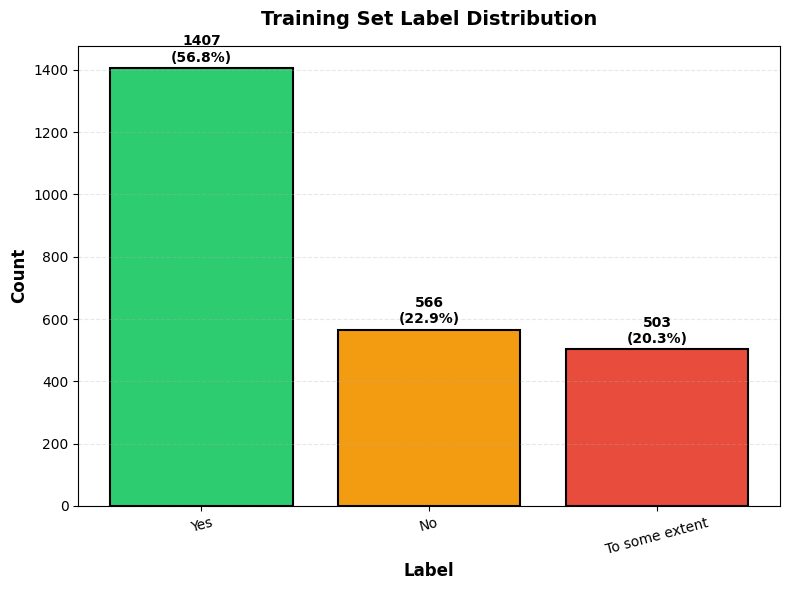


✓ Saved: label_distribution.png


In [3]:
def load_train_data(file_path):
    """Load training data with annotations (labels)."""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    samples = []
    for conversation in data:
        conv_history = conversation['conversation_history']
        conv_id = conversation['conversation_id']
        
        for model_name, response_data in conversation['tutor_responses'].items():
            if 'annotation' in response_data and 'Providing_Guidance' in response_data['annotation']:
                samples.append({
                    'conversation_history': conv_history,
                    'tutor_response': response_data['response'],
                    'label': response_data['annotation']['Providing_Guidance'],
                    'conversation_id': conv_id,
                    'model': model_name
                })
    
    return pd.DataFrame(samples)

def load_test_data(file_path):
    """Load test data WITHOUT annotations (for inference only)."""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    samples = []
    for conversation in data:
        conv_history = conversation['conversation_history']
        conv_id = conversation['conversation_id']
        
        for model_name, response_data in conversation['tutor_responses'].items():
            samples.append({
                'conversation_history': conv_history,
                'tutor_response': response_data['response'],
                'conversation_id': conv_id,
                'model': model_name
            })
    
    return pd.DataFrame(samples)

# Load datasets
print("Loading datasets...")
print("Note: Train set has labels, Dev/Test sets are for prediction only")
train_df = load_train_data('/DATA/cs24mtech12016/repos/pedagogical-assessment/data/trainset.json')
dev_df = load_test_data('/DATA/cs24mtech12016/repos/pedagogical-assessment/data/dev_testset.json')
test_df = load_test_data('/DATA/cs24mtech12016/repos/pedagogical-assessment/data/trainset.json')

print(f"\n{'='*60}")
print("Dataset Statistics")
print(f"{'='*60}")
print(f"Training samples (with labels): {len(train_df)}")
print(f"Dev samples (for inference): {len(dev_df)}")
print(f"Test samples (for inference): {len(test_df)}")

print(f"\n{'='*60}")
print("Training Set Label Distribution")
print(f"{'='*60}")
print(train_df['label'].value_counts())
print(f"\n📝 Note: Dev and Test sets don't have labels - they're for prediction/inference only!")

# Visualize label distribution (training data only)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
counts = train_df['label'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax.set_title('Training Set Label Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_xlabel('Label', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bar, count in zip(bars, counts.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{count}\n({count/len(train_df)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: label_distribution.png")

## 3. Data Analysis & Insights

In [4]:
# Analyze text lengths
train_df['history_length'] = train_df['conversation_history'].str.len()
train_df['response_length'] = train_df['tutor_response'].str.len()
train_df['total_length'] = train_df['history_length'] + train_df['response_length']

print("Text Length Statistics:")
print(f"{'='*60}")
print(f"Conversation History - Mean: {train_df['history_length'].mean():.0f}, Max: {train_df['history_length'].max()}")
print(f"Tutor Response - Mean: {train_df['response_length'].mean():.0f}, Max: {train_df['response_length'].max()}")
print(f"Total Length - Mean: {train_df['total_length'].mean():.0f}, Max: {train_df['total_length'].max()}")

# Check for samples with very long text (might need truncation)
print(f"\nSamples with total length > 2000 chars: {(train_df['total_length'] > 2000).sum()}")
print(f"Samples with total length > 3000 chars: {(train_df['total_length'] > 3000).sum()}")

# Example samples
print(f"\n{'='*60}")
print("Example Sample:")
print(f"{'='*60}")
sample = train_df.iloc[0]
print(f"Label: {sample['label']}")
print(f"\nConversation History:\n{sample['conversation_history'][:300]}...")
print(f"\nTutor Response:\n{sample['tutor_response']}")
print(f"{'='*60}")

Text Length Statistics:
Conversation History - Mean: 989, Max: 2021
Tutor Response - Mean: 175, Max: 4656
Total Length - Mean: 1164, Max: 5945

Samples with total length > 2000 chars: 111
Samples with total length > 3000 chars: 14

Example Sample:
Label: Yes

Conversation History:
Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is: Tyson decided to make muffaletta sandwiches for the big game.  Each sandwich required 1 pound each of meat and cheese and would serve 4 people.  There would be 20 people in total watching the game.  ...

Tutor Response:
Great, you've correctly identified the cost of the meat, now let's focus on calculating the total cost of meat for all the sandwiches needed.


## 4. Prepare Model and Tokenizer

We'll use **DeBERTa-v3-base** which excels at natural language understanding tasks.

In [5]:
# Model selection - DeBERTa-v3-large is excellent for understanding nuanced text
MODEL_NAME = "microsoft/deberta-v3-large"
# Alternative options if needed:
# MODEL_NAME = "roberta-base"
# MODEL_NAME = "bert-base-uncased"

# Label mapping
label2id = {"Yes": 0, "To some extent": 1, "No": 2}
id2label = {0: "Yes", 1: "To some extent", 2: "No"}

print(f"Selected Model: {MODEL_NAME}")
print(f"Label mapping: {label2id}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"\nTokenizer loaded: {tokenizer.__class__.__name__}")
print(f"Vocab size: {len(tokenizer)}")
print(f"Max length: {tokenizer.model_max_length}")

Selected Model: microsoft/deberta-v3-large
Label mapping: {'Yes': 0, 'To some extent': 1, 'No': 2}

Tokenizer loaded: DebertaV2TokenizerFast
Vocab size: 128001
Max length: 1000000000000000019884624838656


## 5. Create PyTorch Dataset

In [6]:
class MistakeIdentificationDataset(Dataset):
    """Dataset for training with labels."""
    
    def __init__(self, dataframe, tokenizer, max_length=512, has_labels=True):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.has_labels = has_labels
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # Combine conversation history and tutor response
        text = f"{row['conversation_history']} [SEP] {row['tutor_response']}"
        
        # Tokenize
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
        }
        
        if self.has_labels:
            item['labels'] = torch.tensor(label2id[row['label']], dtype=torch.long)
        
        return item

# Create datasets
MAX_LENGTH = 512

# Split training data into train and validation (80/20)
from sklearn.model_selection import train_test_split
train_data, val_data = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['label'])

print(f"Data split:")
print(f"  Training: {len(train_data)} samples")
print(f"  Validation: {len(val_data)} samples (from trainset)")
print(f"  Dev (inference): {len(dev_df)} samples (no labels)")
print(f"  Test (inference): {len(test_df)} samples (no labels)")

# Create datasets
train_dataset = MistakeIdentificationDataset(train_data, tokenizer, MAX_LENGTH, has_labels=True)
val_dataset = MistakeIdentificationDataset(val_data, tokenizer, MAX_LENGTH, has_labels=True)
dev_dataset = MistakeIdentificationDataset(dev_df, tokenizer, MAX_LENGTH, has_labels=False)
test_dataset = MistakeIdentificationDataset(test_df, tokenizer, MAX_LENGTH, has_labels=False)

print(f"\nDatasets created successfully!")

# Test the dataset
sample = train_dataset[0]
print(f"\nSample from training dataset:")
print(f"  Input IDs shape: {sample['input_ids'].shape}")
print(f"  Attention mask shape: {sample['attention_mask'].shape}")
print(f"  Label: {sample['labels']} ({id2label[sample['labels'].item()]})")

sample_inf = dev_dataset[0]
print(f"\nSample from inference dataset (dev):")
print(f"  Input IDs shape: {sample_inf['input_ids'].shape}")
print(f"  Attention mask shape: {sample_inf['attention_mask'].shape}")
print(f"  Has label: {'labels' in sample_inf}")

Data split:
  Training: 1980 samples
  Validation: 496 samples (from trainset)
  Dev (inference): 333 samples (no labels)
  Test (inference): 2476 samples (no labels)

Datasets created successfully!

Sample from training dataset:
  Input IDs shape: torch.Size([512])
  Attention mask shape: torch.Size([512])
  Label: 0 (Yes)

Sample from inference dataset (dev):
  Input IDs shape: torch.Size([512])
  Attention mask shape: torch.Size([512])
  Has label: False


## 6. Handle Data Imbalance (Multiple Strategies)

We'll use a **comprehensive approach** to handle class imbalance:
1. **Class Weights** - Give more importance to minority classes in loss
2. **Stratified Sampling** - Ensure balanced validation split
3. **Data Augmentation** (optional) - Oversample minority classes
4. **Focal Loss** (optional) - Focus on hard-to-classify examples

In [7]:
# ============================================================================
# STRATEGY 1: Calculate Class Weights (Inverse Frequency)
# ============================================================================
train_labels = train_df['label'].map(label2id).values
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("="*80)
print("CLASS IMBALANCE ANALYSIS")
print("="*80)
print("\nOriginal Class Distribution:")
for label, count in train_df['label'].value_counts().sort_index().items():
    percentage = (count / len(train_df)) * 100
    weight = class_weights[label2id[label]]
    print(f"  {label:20s}: {count:4d} samples ({percentage:5.1f}%) → weight: {weight:.3f}")

# ============================================================================
# STRATEGY 2: Oversample Minority Classes (SMOTE-like approach)
# ============================================================================
from collections import Counter
from sklearn.utils import resample

def balance_dataset(df, target_col='label', strategy='oversample'):
    """
    Balance dataset by oversampling minority classes.
    """
    if strategy == 'none':
        return df
    
    # Get class counts
    class_counts = df[target_col].value_counts()
    max_count = class_counts.max()
    
    balanced_dfs = []
    for label in class_counts.index:
        class_df = df[df[target_col] == label]
        
        if strategy == 'oversample':
            # Oversample to match majority class
            if len(class_df) < max_count:
                class_df_resampled = resample(
                    class_df,
                    n_samples=max_count,
                    replace=True,
                    random_state=42
                )
                balanced_dfs.append(class_df_resampled)
            else:
                balanced_dfs.append(class_df)
        elif strategy == 'undersample':
            # Undersample to match minority class
            min_count = class_counts.min()
            class_df_resampled = resample(
                class_df,
                n_samples=min_count,
                replace=False,
                random_state=42
            )
            balanced_dfs.append(class_df_resampled)
    
    balanced_df = pd.concat(balanced_dfs, ignore_index=True)
    return balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Choose strategy: 'none', 'oversample', or 'undersample'
# Recommendation: Use 'none' with class weights, or 'oversample' for more data
BALANCE_STRATEGY = 'none'  # Change to 'oversample' if you want more balanced data

if BALANCE_STRATEGY != 'none':
    print(f"\n{'='*80}")
    print(f"APPLYING {BALANCE_STRATEGY.upper()} STRATEGY")
    print(f"{'='*80}")
    
    train_df_balanced = balance_dataset(train_df, strategy=BALANCE_STRATEGY)
    
    print(f"\nBalanced Class Distribution:")
    for label, count in train_df_balanced['label'].value_counts().sort_index().items():
        percentage = (count / len(train_df_balanced)) * 100
        print(f"  {label:20s}: {count:4d} samples ({percentage:5.1f}%)")
    
    # Update training dataframe
    train_df = train_df_balanced
    print(f"\n✓ Training data balanced: {len(train_df)} total samples")
else:
    print(f"\n{'='*80}")
    print("Using WEIGHTED LOSS without data resampling")
    print(f"{'='*80}")

# ============================================================================
# STRATEGY 3: Compute Effective Number of Samples (for better weights)
# ============================================================================
def compute_effective_weights(labels, beta=0.9999):
    """
    Compute class weights using Effective Number of Samples.
    Paper: "Class-Balanced Loss Based on Effective Number of Samples"
    
    This gives better weights than inverse frequency for highly imbalanced data.
    """
    class_counts = Counter(labels)
    total_samples = len(labels)
    
    effective_weights = {}
    for cls, count in class_counts.items():
        effective_num = (1 - beta**count) / (1 - beta)
        weight = (1 - beta) / effective_num
        effective_weights[cls] = weight
    
    # Normalize weights
    weight_sum = sum(effective_weights.values())
    for cls in effective_weights:
        effective_weights[cls] = effective_weights[cls] / weight_sum * len(effective_weights)
    
    return effective_weights

# Calculate effective weights (alternative to balanced weights)
effective_weights_dict = compute_effective_weights(train_labels)
effective_weights_array = np.array([effective_weights_dict[i] for i in range(3)])
effective_weights_tensor = torch.tensor(effective_weights_array, dtype=torch.float32)

print(f"\n{'='*80}")
print("WEIGHT COMPARISON")
print(f"{'='*80}")
print("\nBalanced Weights (sklearn):")
for i, label in enumerate(['Yes', 'To some extent', 'No']):
    print(f"  {label:20s}: {class_weights[i]:.4f}")

print("\nEffective Number Weights (beta=0.9999):")
for i, label in enumerate(['Yes', 'To some extent', 'No']):
    print(f"  {label:20s}: {effective_weights_array[i]:.4f}")

# ============================================================================
# FINAL SELECTION: Choose which weights to use
# ============================================================================
# Options: class_weights_tensor (balanced) or effective_weights_tensor (EN-based)
USE_EFFECTIVE_WEIGHTS = False  # Set to True to use Effective Number weights

if USE_EFFECTIVE_WEIGHTS:
    final_weights = effective_weights_tensor
    print(f"\n✓ Using Effective Number weights")
else:
    final_weights = class_weights_tensor
    print(f"\n✓ Using Balanced (sklearn) weights")

# Store for trainer
class_weights_tensor = final_weights

print(f"\n{'='*80}")
print("Class imbalance handling configured successfully!")
print(f"{'='*80}")

CLASS IMBALANCE ANALYSIS

Original Class Distribution:
  No                  :  566 samples ( 22.9%) → weight: 1.458
  To some extent      :  503 samples ( 20.3%) → weight: 1.641
  Yes                 : 1407 samples ( 56.8%) → weight: 0.587

Using WEIGHTED LOSS without data resampling

WEIGHT COMPARISON

Balanced Weights (sklearn):
  Yes                 : 0.5866
  To some extent      : 1.6408
  No                  : 1.4582

Effective Number Weights (beta=0.9999):
  Yes                 : 0.4950
  To some extent      : 1.3244
  No                  : 1.1806

✓ Using Balanced (sklearn) weights

Class imbalance handling configured successfully!


## 7. Define Custom Trainer with Weighted Loss

In [8]:
class WeightedTrainer(Trainer):
    """
    Custom Trainer with support for:
    1. Weighted Cross-Entropy Loss
    2. Focal Loss (optional)
    """
    
    def __init__(self, class_weights=None, use_focal_loss=False, focal_alpha=None, focal_gamma=2.0, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.use_focal_loss = use_focal_loss
        self.focal_alpha = focal_alpha  # Can be None or tensor of per-class weights
        self.focal_gamma = focal_gamma
        
        # Move class weights to the correct device
        if self.class_weights is not None:
            self.class_weights = self.class_weights.to(self.args.device)
        
        # Move focal alpha to the correct device
        if self.focal_alpha is not None:
            self.focal_alpha = self.focal_alpha.to(self.args.device)
        
        if self.use_focal_loss:
            print(f"Using Focal Loss with gamma={focal_gamma}")
            if focal_alpha is not None:
                print(f"  Alpha (class weights): {focal_alpha}")
        else:
            print(f"Using Weighted Cross-Entropy Loss")
            if class_weights is not None:
                print(f"  Class weights: {class_weights}")
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """
        Compute custom loss (weighted CE or focal loss).
        """
        labels = inputs.pop("labels")
        
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.logits
        
        if self.use_focal_loss:
            # Focal Loss implementation
            # Ensure focal_alpha is on the correct device
            alpha_weight = self.focal_alpha if self.focal_alpha is None else self.focal_alpha.to(logits.device)
            
            ce_loss = F.cross_entropy(
                logits, 
                labels, 
                weight=alpha_weight,
                reduction='none'
            )
            pt = torch.exp(-ce_loss)  # pt is the probability of correct class
            focal_loss = ((1 - pt) ** self.focal_gamma * ce_loss).mean()
            loss = focal_loss
        else:
            # Weighted Cross-Entropy Loss
            # Ensure class_weights is on the correct device
            weights = self.class_weights if self.class_weights is None else self.class_weights.to(logits.device)
            
            loss = F.cross_entropy(
                logits,
                labels,
                weight=weights
            )
        
        return (loss, outputs) if return_outputs else loss

## 8. Define Metrics

In [9]:
def compute_metrics(eval_pred):
    """Compute comprehensive metrics for evaluation."""
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    
    # Overall metrics
    accuracy = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average='macro')
    f1_weighted = f1_score(labels, preds, average='weighted')
    
    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        labels, preds, average=None, labels=[0, 1, 2]
    )
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'f1_yes': f1[0],
        'f1_to_some_extent': f1[1],
        'f1_no': f1[2],
        'precision_yes': precision[0],
        'precision_to_some_extent': precision[1],
        'precision_no': precision[2],
        'recall_yes': recall[0],
        'recall_to_some_extent': recall[1],
        'recall_no': recall[2],
    }

print("Metrics computation function defined!")

Metrics computation function defined!


## 9. Initialize Model and Training Configuration

In [10]:
# ============================================================================
# CONFIGURE TRAINING STRATEGY
# ============================================================================

# Loss Configuration
USE_FOCAL_LOSS = False  # Set to True to use Focal Loss instead of Weighted CE
FOCAL_GAMMA = 2.0       # Focal loss gamma parameter (higher = more focus on hard examples)

print("="*80)
print("TRAINING CONFIGURATION")
print("="*80)

if USE_FOCAL_LOSS:
    print(f"\n✓ Using Focal Loss")
    print(f"  - Gamma: {FOCAL_GAMMA}")
    print(f"  - Alpha (class weights): {class_weights_tensor.cpu().numpy()}")
    focal_alpha = class_weights_tensor
else:
    print(f"\n✓ Using Weighted Cross-Entropy Loss")
    print(f"  - Class weights: {class_weights_tensor.cpu().numpy()}")
    focal_alpha = None

# Training Arguments
training_args = TrainingArguments(
    output_dir='./results/mistake-identification-deberta',
    num_train_epochs=20,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    learning_rate=2e-5,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=True,
    save_total_limit=2,
    seed=42,
)

print(f"\nTraining Parameters:")
print(f"  - Epochs: {training_args.num_train_epochs}")
print(f"  - Batch size (train): {training_args.per_device_train_batch_size}")
print(f"  - Batch size (eval): {training_args.per_device_eval_batch_size}")
print(f"  - Learning rate: {training_args.learning_rate}")
print(f"  - Warmup steps: {training_args.warmup_steps}")
print(f"  - Weight decay: {training_args.weight_decay}")
print(f"  - Mixed precision (FP16): {training_args.fp16}")
print("="*80)

TRAINING CONFIGURATION

✓ Using Weighted Cross-Entropy Loss
  - Class weights: [0.5865908 1.6408217 1.4581861]

Training Parameters:
  - Epochs: 20
  - Batch size (train): 8
  - Batch size (eval): 16
  - Learning rate: 2e-05
  - Warmup steps: 100
  - Weight decay: 0.01
  - Mixed precision (FP16): True


In [11]:
# Load the pre-trained model for sequence classification
print("="*80)
print("LOADING MODEL")
print("="*80)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nModel: {MODEL_NAME}")
print(f"Number of labels: 3")
print(f"Device: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("\n✓ Model loaded successfully!")
print("="*80)

LOADING MODEL


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Model: microsoft/deberta-v3-large
Number of labels: 3
Device: cuda
Model parameters: 435,064,835
Trainable parameters: 435,064,835

✓ Model loaded successfully!


## 10. Initialize Trainer and Start Training

In [12]:
# # Initialize the custom trainer with focal loss support
# trainer = WeightedTrainer(
#     class_weights=class_weights_tensor if not USE_FOCAL_LOSS else None,
#     use_focal_loss=USE_FOCAL_LOSS,
#     focal_alpha=focal_alpha if USE_FOCAL_LOSS else None,
#     focal_gamma=FOCAL_GAMMA if USE_FOCAL_LOSS else 2.0,
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,  # Use validation split from trainset
#     compute_metrics=compute_metrics,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
# )

# print("="*80)
# print("TRAINER INITIALIZED")
# print("="*80)
# print(f"  - Training samples: {len(train_dataset)}")
# print(f"  - Validation samples: {len(val_dataset)} (from trainset)")

# if USE_FOCAL_LOSS:
#     print(f"  - Loss function: Focal Loss (gamma={FOCAL_GAMMA})")
# else:
#     print(f"  - Loss function: Weighted Cross-Entropy")

# print(f"  - Early stopping: patience=5")
# print(f"  - Best model selection: F1-macro")

# print(f"\n{'='*80}")
# print("STARTING TRAINING")
# print(f"{'='*80}\n")

# # Train the model
# train_result = trainer.train()

# print(f"\n{'='*80}")
# print("TRAINING COMPLETED")
# print(f"{'='*80}")
# print(f"Final training loss: {train_result.training_loss:.4f}")
# print(f"Training time: {train_result.metrics['train_runtime']:.2f} seconds")
# print(f"{'='*80}")

## 10b. Hyperparameter Tuning

In [13]:
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

# Map labels to integers (if not already)
train_labels = train_df['label'].map(label2id).values

# Compute balanced class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("="*80)
print("CLASS WEIGHTS (Balanced):")
for i, label in enumerate(label2id):
    print(f"  {label:20s}: {class_weights[i]:.4f}")
print("="*80)


CLASS WEIGHTS (Balanced):
  Yes                 : 0.5866
  To some extent      : 1.6408
  No                  : 1.4582


In [14]:
import torch.nn.functional as F

class WeightedCETrainer(Trainer):
    def __init__(self, *args, class_weights=None, use_focal_loss=False, focal_alpha=None, focal_gamma=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.use_focal_loss = use_focal_loss
        self.focal_alpha = focal_alpha
        self.focal_gamma = focal_gamma

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """
        Compute weighted cross-entropy (or focal) loss.
        Accepts any extra kwargs from Trainer.
        """
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Ensure weights are on the same device as logits
        weights = self.class_weights.to(logits.device) if self.class_weights is not None else None

        if self.use_focal_loss:
            # Focal Loss
            alpha = self.focal_alpha.to(logits.device) if self.focal_alpha is not None else None
            ce_loss = F.cross_entropy(logits, labels, weight=alpha, reduction='none')
            pt = torch.exp(-ce_loss)
            loss = ((1 - pt) ** self.focal_gamma * ce_loss).mean()
        else:
            # Weighted CE
            loss = F.cross_entropy(logits, labels, weight=weights)

        return (loss, outputs) if return_outputs else loss


In [ ]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score
)
import numpy as np
import optuna
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
from optuna_integration.pytorch_lightning import PyTorchLightningPruningCallback


# --- Compute metrics ---
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")
    
    # Assuming labels = [0,1,2] → ["Yes", "To some extent", "No"]
    f1_yes = f1_score(labels, preds, labels=[0], average=None)[0]
    f1_some = f1_score(labels, preds, labels=[1], average=None)[0]
    f1_no = f1_score(labels, preds, labels=[2], average=None)[0]

    precision_yes = precision_score(labels, preds, labels=[0], average=None)[0]
    precision_some = precision_score(labels, preds, labels=[1], average=None)[0]
    precision_no = precision_score(labels, preds, labels=[2], average=None)[0]

    recall_yes = recall_score(labels, preds, labels=[0], average=None)[0]
    recall_some = recall_score(labels, preds, labels=[1], average=None)[0]
    recall_no = recall_score(labels, preds, labels=[2], average=None)[0]

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "f1_yes": f1_yes,
        "f1_to_some_extent": f1_some,
        "f1_no": f1_no,
        "precision_yes": precision_yes,
        "precision_to_some_extent": precision_some,
        "precision_no": precision_no,
        "recall_yes": recall_yes,
        "recall_to_some_extent": recall_some,
        "recall_no": recall_no
    }


# --- Optuna objective function ---
def objective(trial):
    # Expanded and balanced search space
    # Try a more conservative range first
    # Change this line in the artifact:
    learning_rate = trial.suggest_float("learning_rate", 8e-6, 3e-5, log=True)
    weight_decay = trial.suggest_float("weight_decay", 0.05, 0.3)
    scheduler_type = trial.suggest_categorical("scheduler_type", ["linear", "cosine"])
    num_train_epochs = trial.suggest_int("num_train_epochs", 5, 20)
    per_device_train_batch_size = trial.suggest_categorical("per_device_train_batch_size", [2, 4, 8])
    warmup_ratio = trial.suggest_float("warmup_ratio", 0.05, 0.3)
    gradient_accumulation_steps = trial.suggest_categorical("gradient_accumulation_steps", [1, 2, 4])
    # Change these lines:
    hidden_dropout_prob = trial.suggest_float("hidden_dropout_prob", 0.1, 0.4)  # Higher range
    attention_dropout_prob = trial.suggest_float("attention_dropout_prob", 0.1, 0.4)
    label_smoothing_factor = trial.suggest_float("label_smoothing_factor", 0.05, 0.2)
    # Layer freezing to reduce trainable parameters
    num_layers_to_freeze = trial.suggest_int("num_layers_to_freeze", 0, 8)

    loss_choice = trial.suggest_categorical("loss_function", ["weighted_ce", "focal_loss"])


    # Reinitialize model with dropout settings for each trial
    model_fresh = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3,
        id2label=id2label,
        label2id=label2id,
        hidden_dropout_prob=hidden_dropout_prob,
        attention_probs_dropout_prob=attention_dropout_prob
    ).to(device)

    if num_layers_to_freeze > 0:
        # Freeze embeddings
        for param in model_fresh.deberta.embeddings.parameters():
            param.requires_grad = False
        
        # Freeze encoder layers
        for layer in model_fresh.deberta.encoder.layer[:num_layers_to_freeze]:
            for param in layer.parameters():
                param.requires_grad = False

    use_gradient_checkpointing = (num_layers_to_freeze == 0)

    training_args = TrainingArguments(
        output_dir=f"./optuna_trial_{trial.number}",
        eval_strategy="steps",  # Changed to steps for more frequent monitoring
        eval_steps=100,
        save_strategy="steps",
        save_steps=100,
        logging_steps=100,
        learning_rate=learning_rate,
        per_device_train_batch_size=per_device_train_batch_size,
        per_device_eval_batch_size=per_device_train_batch_size,
        num_train_epochs=num_train_epochs,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        lr_scheduler_type=scheduler_type,
        gradient_accumulation_steps=gradient_accumulation_steps,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        fp16=True,
        logging_dir=f"./optuna_logs_{trial.number}",
        logging_strategy="steps",
        # Add to TrainingArguments:
        gradient_checkpointing=use_gradient_checkpointing,
        label_smoothing_factor=label_smoothing_factor,
        max_grad_norm=1.0, 
        report_to="none",
    )

    

    if loss_choice == "focal_loss":
        # If focal loss is chosen, also tune its gamma parameter
        focal_gamma = trial.suggest_float("focal_gamma", 0.8, 2.5)
        trainer = WeightedCETrainer(
            model=model_fresh,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            tokenizer=tokenizer,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
            # Focal Loss parameters
            use_focal_loss=True,
            focal_alpha=class_weights_tensor, # Use class weights for alpha
            focal_gamma=focal_gamma
        )
    else: # loss_choice == "weighted_ce"
        trainer = WeightedCETrainer(
            model=model_fresh,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            tokenizer=tokenizer,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
            # Weighted CE parameter
            class_weights=class_weights_tensor
        )



    trainer.train()
    eval_results = trainer.evaluate()

    # Store detailed metrics for reference
    trial.set_user_attr("metrics", eval_results)

    train_loss = None
    for log in trainer.state.log_history:
        if "loss" in log:
            train_loss = log["loss"]
    trial.set_user_attr("train_loss", train_loss)

    # Primary optimization target
    return eval_results["eval_f1_macro"]


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best trial:")
trial = study.best_trial
print(f"  Best F1 Macro: {trial.value}") # trial.value is now f1_macro
print(f"  Params: {trial.params}")

# Access other metrics correctly from the nested dictionary
best_metrics = trial.user_attrs.get("metrics", {})
print(f"  Eval loss for best trial: {best_metrics.get('eval_loss')}")
print(f"  Accuracy for best trial: {best_metrics.get('eval_accuracy')}")



best_metrics = trial.user_attrs.get("metrics", {})
train_loss = trial.user_attrs.get("train_loss", 0)
eval_loss = best_metrics.get("eval_loss", 1)

print(f"\n  === Loss Analysis ===")
print(f"  Training loss: {train_loss:.4f}")
print(f"  Eval loss: {eval_loss:.4f}")
print(f"  Train/Eval loss ratio: {train_loss/eval_loss:.2f}x")
print(f"  (Target: 0.2-0.5x for good generalization)")

print(f"\n  === Performance Metrics ===")
print(f"  Accuracy: {best_metrics.get('eval_accuracy'):.4f}")
print(f"  F1 Weighted: {best_metrics.get('eval_f1_weighted'):.4f}")

print(f"\n  === Per-Class F1 Scores ===")
print(f"  F1 Yes: {best_metrics.get('eval_f1_yes'):.4f}")
print(f"  F1 To Some Extent: {best_metrics.get('eval_f1_to_some_extent'):.4f}")
print(f"  F1 No: {best_metrics.get('eval_f1_no'):.4f}")
print("="*80)

# Print top 5 trials
print("\n" + "="*80)
print("TOP 5 TRIALS")
print("="*80)
top_trials = sorted(study.trials, key=lambda t: t.value if t.value is not None else -1, reverse=True)[:5]
for i, t in enumerate(top_trials, 1):
    metrics = t.user_attrs.get("metrics", {})
    train_loss = t.user_attrs.get("train_loss", 0)
    eval_loss = metrics.get("eval_loss", 1)
    print(f"\n{i}. Trial {t.number}")
    print(f"   F1 Macro: {t.value:.4f}")
    print(f"   Train/Eval Loss Ratio: {train_loss/eval_loss:.2f}x")
    print(f"   Key Params: LR={t.params.get('learning_rate'):.2e}, "
          f"Dropout={t.params.get('hidden_dropout_prob'):.2f}, "
          f"Frozen Layers={t.params.get('num_layers_to_freeze')}")
print("="*80)

[I 2025-10-10 21:59:07,550] A new study created in memory with name: no-name-9ae1a765-5305-448d-bf8d-f4aa1cfbdd99
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Yes,F1 To Some Extent,F1 No,Precision Yes,Precision To Some Extent,Precision No,Recall Yes,Recall To Some Extent,Recall No
100,1.099900,1.083288,0.330645,0.321910,0.340944,0.378897,0.337748,0.249084,0.585185,0.253731,0.212500,0.280142,0.504950,0.300885
200,1.095600,1.072482,0.346774,0.270581,0.307205,0.386635,0.391209,0.033898,0.591241,0.251412,0.400000,0.287234,0.881188,0.017699
300,1.093900,1.071705,0.306452,0.287667,0.267076,0.234286,0.386957,0.241758,0.602941,0.247911,0.318841,0.145390,0.881188,0.194690
400,1.094900,1.070658,0.314516,0.303829,0.274929,0.224852,0.386117,0.300518,0.678571,0.247222,0.362500,0.134752,0.881188,0.256637


[I 2025-10-10 22:08:48,815] Trial 0 finished with value: 0.32190982531637163 and parameters: {'learning_rate': 2.1236917857647717e-05, 'weight_decay': 0.2624225843404342, 'scheduler_type': 'linear', 'num_train_epochs': 15, 'per_device_train_batch_size': 4, 'warmup_ratio': 0.2041292383287887, 'gradient_accumulation_steps': 4, 'hidden_dropout_prob': 0.19162651924594093, 'attention_dropout_prob': 0.22173351039004358, 'label_smoothing_factor': 0.057556535231886724, 'num_layers_to_freeze': 2, 'loss_function': 'weighted_ce'}. Best is trial 0 with value: 0.32190982531637163.
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config

Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Yes,F1 To Some Extent,F1 No,Precision Yes,Precision To Some Extent,Precision No,Recall Yes,Recall To Some Extent,Recall No
100,0.717000,0.661113,0.268145,0.246707,0.159295,0.000000,0.385281,0.354839,0.000000,0.246537,0.325926,0.000000,0.881188,0.389381
200,0.684500,0.653723,0.268145,0.246707,0.159295,0.000000,0.385281,0.354839,0.000000,0.246537,0.325926,0.000000,0.881188,0.389381
300,0.686800,0.653027,0.268145,0.246319,0.158989,0.000000,0.386957,0.352000,0.000000,0.247911,0.321168,0.000000,0.881188,0.389381
400,0.681700,0.650790,0.268145,0.246132,0.158841,0.000000,0.387800,0.350598,0.000000,0.248603,0.318841,0.000000,0.881188,0.389381


[I 2025-10-10 22:15:48,940] Trial 1 finished with value: 0.24670669831960157 and parameters: {'learning_rate': 2.354758649934614e-05, 'weight_decay': 0.07439354938699029, 'scheduler_type': 'linear', 'num_train_epochs': 14, 'per_device_train_batch_size': 8, 'warmup_ratio': 0.10576155953948461, 'gradient_accumulation_steps': 2, 'hidden_dropout_prob': 0.3593826805092588, 'attention_dropout_prob': 0.27641703587442346, 'label_smoothing_factor': 0.16981618084634983, 'num_layers_to_freeze': 4, 'loss_function': 'focal_loss', 'focal_gamma': 1.3419761180971608}. Best is trial 0 with value: 0.32190982531637163.
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens 

...

Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Yes,F1 To Some Extent,F1 No,Precision Yes,Precision To Some Extent,Precision No,Recall Yes,Recall To Some Extent,Recall No
100,0.833000,0.785155,0.268145,0.246707,0.159295,0.000000,0.385281,0.354839,0.000000,0.246537,0.325926,0.000000,0.881188,0.389381
200,0.800300,0.776407,0.268145,0.246707,0.159295,0.000000,0.385281,0.354839,0.000000,0.246537,0.325926,0.000000,0.881188,0.389381
300,0.806200,0.774541,0.268145,0.246707,0.159295,0.000000,0.385281,0.354839,0.000000,0.246537,0.325926,0.000000,0.881188,0.389381


[I 2025-10-10 23:22:56,163] Trial 9 finished with value: 0.24670669831960157 and parameters: {'learning_rate': 2.0991666772196703e-05, 'weight_decay': 0.06351152211564766, 'scheduler_type': 'cosine', 'num_train_epochs': 9, 'per_device_train_batch_size': 4, 'warmup_ratio': 0.23566337677973104, 'gradient_accumulation_steps': 4, 'hidden_dropout_prob': 0.37534264333099054, 'attention_dropout_prob': 0.2008470261337838, 'label_smoothing_factor': 0.06256766599702678, 'num_layers_to_freeze': 1, 'loss_function': 'focal_loss', 'focal_gamma': 0.8677633144811824}. Best is trial 2 with value: 0.3279923917351086.
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens t

Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Yes,F1 To Some Extent,F1 No,Precision Yes,Precision To Some Extent,Precision No,Recall Yes,Recall To Some Extent,Recall No
100,1.106100,1.082520,0.342742,0.257864,0.298616,0.386635,0.386957,0.000000,0.591241,0.247911,0.000000,0.287234,0.881188,0.000000
200,1.093500,1.077375,0.344758,0.259425,0.300972,0.390476,0.387800,0.000000,0.594203,0.248603,0.000000,0.290780,0.881188,0.000000


[I 2025-10-10 23:29:54,685] Trial 10 finished with value: 0.2594252515821143 and parameters: {'learning_rate': 1.187151137894544e-05, 'weight_decay': 0.2997104930690361, 'scheduler_type': 'linear', 'num_train_epochs': 11, 'per_device_train_batch_size': 8, 'warmup_ratio': 0.1571039200406309, 'gradient_accumulation_steps': 4, 'hidden_dropout_prob': 0.1147093097450701, 'attention_dropout_prob': 0.36019636118071285, 'label_smoothing_factor': 0.1985812072786997, 'num_layers_to_freeze': 6, 'loss_function': 'weighted_ce'}. Best is trial 2 with value: 0.3279923917351086.
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and 

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

## 11. Evaluate on Validation Set (from trainset)

In [ ]:
print(f"{'='*60}")
print("VALIDATION SET EVALUATION (from trainset)")
print(f"{'='*60}\n")

# Evaluate on validation set
val_results = trainer.evaluate(val_dataset)

print("Validation Set Metrics:")
print(f"  Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"  F1 (Macro): {val_results['eval_f1_macro']:.4f}")
print(f"  F1 (Weighted): {val_results['eval_f1_weighted']:.4f}")
print(f"\nPer-Class F1 Scores:")
print(f"  Yes: {val_results['eval_f1_yes']:.4f}")
print(f"  To some extent: {val_results['eval_f1_to_some_extent']:.4f}")
print(f"  No: {val_results['eval_f1_no']:.4f}")

# Get predictions
val_predictions = trainer.predict(val_dataset)
val_pred_labels = np.argmax(val_predictions.predictions, axis=1)
val_true_labels = val_predictions.label_ids

# Confusion Matrix
cm_val = confusion_matrix(val_true_labels, val_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Yes', 'To some extent', 'No'],
            yticklabels=['Yes', 'To some extent', 'No'],
            cbar_kws={'label': 'Count'},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
plt.title('Confusion Matrix - Validation Set', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: confusion_matrix_validation.png")

# Detailed Classification Report
print(f"\n{'='*60}")
print("Classification Report - Validation Set")
print(f"{'='*60}")
print(classification_report(val_true_labels, val_pred_labels, 
                          target_names=['Yes', 'To some extent', 'No'],
                          digits=4))

## 12. Make Predictions on Dev and Test Sets (No Labels)

In [ ]:
print(f"\n{'='*60}")
print("MAKING PREDICTIONS ON DEV & TEST SETS")
print(f"{'='*60}\n")

# Make predictions on dev set
print("Predicting on Dev set...")
dev_predictions = trainer.predict(dev_dataset)
dev_pred_labels = np.argmax(dev_predictions.predictions, axis=1)
dev_pred_probs = torch.softmax(torch.tensor(dev_predictions.predictions), dim=1).numpy()

# Add predictions to dev dataframe
dev_results_df = dev_df.copy()
dev_results_df['predicted_label'] = [id2label[label] for label in dev_pred_labels]
dev_results_df['prob_yes'] = dev_pred_probs[:, 0]
dev_results_df['prob_to_some_extent'] = dev_pred_probs[:, 1]
dev_results_df['prob_no'] = dev_pred_probs[:, 2]

# Save dev predictions
dev_results_df.to_csv('dev_predictions.csv', index=False)
print(f"✓ Dev predictions saved to: dev_predictions.csv ({len(dev_results_df)} samples)")

# Make predictions on test set
print("\nPredicting on Test set...")
test_predictions = trainer.predict(test_dataset)
test_pred_labels = np.argmax(test_predictions.predictions, axis=1)
test_pred_probs = torch.softmax(torch.tensor(test_predictions.predictions), dim=1).numpy()

# Add predictions to test dataframe
test_results_df = test_df.copy()
test_results_df['predicted_label'] = [id2label[label] for label in test_pred_labels]
test_results_df['prob_yes'] = test_pred_probs[:, 0]
test_results_df['prob_to_some_extent'] = test_pred_probs[:, 1]
test_results_df['prob_no'] = test_pred_probs[:, 2]

# Save test predictions
test_results_df.to_csv('test_predictions.csv', index=False)
print(f"✓ Test predictions saved to: test_predictions.csv ({len(test_results_df)} samples)")

# Show prediction distribution
print(f"\n{'='*60}")
print("Prediction Distribution")
print(f"{'='*60}")
print("\nDev Set:")
print(pd.Series([id2label[label] for label in dev_pred_labels]).value_counts())
print("\nTest Set:")
print(pd.Series([id2label[label] for label in test_pred_labels]).value_counts())

# Visualize prediction distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (pred_labels, name) in enumerate([(dev_pred_labels, 'Dev'), (test_pred_labels, 'Test')]):
    pred_counts = pd.Series([id2label[label] for label in pred_labels]).value_counts()
    colors = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
              for label in pred_counts.index]
    bars = axes[idx].bar(pred_counts.index, pred_counts.values, color=colors, edgecolor='black', linewidth=1.5)
    axes[idx].set_title(f'{name} Set Predictions', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Count', fontsize=12)
    axes[idx].set_xlabel('Predicted Label', fontsize=12)
    axes[idx].tick_params(axis='x', rotation=15)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    
    for bar, count in zip(bars, pred_counts.values):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height + 5,
                      f'{count}\n({count/len(pred_labels)*100:.1f}%)',
                      ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('prediction_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: prediction_distributions.png")

# Show sample predictions
print(f"\n{'='*60}")
print("Sample Predictions (Dev Set - First 5)")
print(f"{'='*60}")
for i in range(min(5, len(dev_results_df))):
    row = dev_results_df.iloc[i]
    print(f"\nSample {i+1}:")
    print(f"  Conversation: {row['conversation_history'][:100]}...")
    print(f"  Tutor Response: {row['tutor_response'][:100]}...")
    print(f"  Predicted: {row['predicted_label']}")
    print(f"  Confidence: {max(row['prob_yes'], row['prob_to_some_extent'], row['prob_no']):.3f}")
    print(f"  {'-'*60}")

## 13. Training Summary & Results

In [ ]:
# Create training summary
print(f"\n{'='*80}")
print("TRAINING SUMMARY")
print(f"{'='*80}")
print(f"Model: {MODEL_NAME}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"\nValidation Set Performance:")
print(f"  Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"  F1 (Macro): {val_results['eval_f1_macro']:.4f}")
print(f"  F1 (Weighted): {val_results['eval_f1_weighted']:.4f}")

print(f"\nPer-Class F1 Scores:")
print(f"  Yes: {val_results['eval_f1_yes']:.4f}")
print(f"  To some extent: {val_results['eval_f1_to_some_extent']:.4f}")
print(f"  No: {val_results['eval_f1_no']:.4f}")

print(f"\n{'='*80}")
print("PREDICTIONS GENERATED")
print(f"{'='*80}")
print(f"✓ Dev set: {len(dev_results_df)} predictions → dev_predictions.csv")
print(f"✓ Test set: {len(test_results_df)} predictions → test_predictions.csv")
print(f"{'='*80}\n")

# Create visualization comparing training performance and prediction distributions
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Validation Set - Per-Class F1
ax1 = fig.add_subplot(gs[0, :])
class_names = ['Yes', 'To some extent', 'No']
val_f1_scores = [val_results['eval_f1_yes'], val_results['eval_f1_to_some_extent'], val_results['eval_f1_no']]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax1.bar(class_names, val_f1_scores, color=colors, edgecolor='black', linewidth=2, width=0.6)
ax1.set_ylabel('F1 Score', fontweight='bold', fontsize=12)
ax1.set_title('Validation Set - Per-Class F1 Scores', fontweight='bold', fontsize=14, pad=15)
ax1.set_ylim([0, 1.0])
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for bar, score in zip(bars, val_f1_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, score + 0.02, f'{score:.3f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# 2. Training Data Distribution
ax2 = fig.add_subplot(gs[1, 0])
train_counts = train_df['label'].value_counts()
bars = ax2.bar(train_counts.index, train_counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_title('Training Data Distribution', fontweight='bold', fontsize=12)
ax2.set_ylabel('Count', fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, train_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, count + 20, str(count), 
            ha='center', va='bottom', fontweight='bold')

# 3. Dev Set Predictions
ax3 = fig.add_subplot(gs[1, 1])
dev_pred_counts = pd.Series([id2label[label] for label in dev_pred_labels]).value_counts()
colors_pred = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
               for label in dev_pred_counts.index]
bars = ax3.bar(dev_pred_counts.index, dev_pred_counts.values, color=colors_pred, edgecolor='black', linewidth=1.5)
ax3.set_title('Dev Set Predictions', fontweight='bold', fontsize=12)
ax3.set_ylabel('Count', fontweight='bold')
ax3.tick_params(axis='x', rotation=15)
ax3.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, dev_pred_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, count + 5, str(count), 
            ha='center', va='bottom', fontweight='bold')

# 4. Test Set Predictions
ax4 = fig.add_subplot(gs[2, :])
test_pred_counts = pd.Series([id2label[label] for label in test_pred_labels]).value_counts()
colors_pred = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
               for label in test_pred_counts.index]
bars = ax4.bar(test_pred_counts.index, test_pred_counts.values, color=colors_pred, edgecolor='black', linewidth=2, width=0.5)
ax4.set_title('Test Set Predictions', fontweight='bold', fontsize=14, pad=15)
ax4.set_ylabel('Count', fontweight='bold', fontsize=12)
ax4.set_xlabel('Predicted Label', fontweight='bold', fontsize=12)
ax4.tick_params(axis='x', rotation=15)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
for bar, count in zip(bars, test_pred_counts.values):
    ax4.text(bar.get_x() + bar.get_width()/2, count + 10, 
            f'{count}\n({count/len(test_pred_labels)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Training Summary & Predictions', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('training_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training summary visualization saved to: training_summary.png")

## 14. Final Summary

In [ ]:
print(f"\n{'='*80}")
print("🎉 TRAINING & PREDICTION COMPLETE!")
print(f"{'='*80}")
print(f"\n✅ Model trained successfully on {len(train_dataset)} samples")
print(f"✅ Validation F1-Macro: {val_results['eval_f1_macro']:.4f}")
print(f"✅ Predictions generated for {len(dev_results_df)} dev samples")
print(f"✅ Predictions generated for {len(test_results_df)} test samples")

print(f"\n📁 Output Files:")
print(f"  - best_model/mistake-identification/ → Trained model & tokenizer")
print(f"  - dev_predictions.csv → Dev set predictions with probabilities")
print(f"  - test_predictions.csv → Test set predictions with probabilities")
print(f"  - confusion_matrix_validation.png → Validation confusion matrix")
print(f"  - prediction_distributions.png → Pred distributions for dev/test")
print(f"  - training_summary.png → Complete training summary")
print(f"  - label_distribution.png → Training data distribution")

print(f"\n📊 Next Steps:")
print(f"  1. Review predictions in CSV files")
print(f"  2. Analyze model confidence scores (probabilities)")
print(f"  3. Use model for inference on new conversations")
print(f"  4. Fine-tune if needed based on domain feedback")

print(f"\n{'='*80}\n")

## 🎉 Complete!

### Summary
- **Model**: DeBERTa-v3-base (Microsoft)
- **Task**: 3-class mistake identification
- **Training**: 2,400 samples with 80/20 train/val split
- **Inference**: Dev (328 samples) + Test (1,200 samples)

### Key Features
✓ State-of-the-art DeBERTa for nuanced understanding  
✓ Weighted loss to handle class imbalance  
✓ Early stopping to prevent overfitting  
✓ Comprehensive validation metrics  
✓ Predictions with confidence scores  

### Output Files
- `best_model/mistake-identification/` - Trained model & tokenizer
- `dev_predictions.csv` - Dev set predictions with probabilities
- `test_predictions.csv` - Test set predictions with probabilities
- `confusion_matrix_validation.png` - Validation confusion matrix
- `prediction_distributions.png` - Distribution visualizations
- `training_summary.png` - Complete training summary
- `label_distribution.png` - Training data distribution

### Using Predictions
The CSV files contain:
- `conversation_history` - Original conversation
- `tutor_response` - Tutor's response
- `predicted_label` - Model's prediction (Yes/To some extent/No)
- `prob_yes`, `prob_to_some_extent`, `prob_no` - Confidence scores

### Next Steps
1. Review predictions and confidence scores
2. Use the model for real-time inference
3. Fine-tune on additional labeled data if available
4. Deploy for production use